# 1.Importing libraries

In [1]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from xgboost import XGBClassifier

# 2.Loading the Datasets

In [2]:
data_df = pd.read_excel("Data.xlsm")

In [3]:
additional_info_df = pd.read_excel("Additional_Info.xlsx")

# 3.Merging the data

In [4]:
bad_debt_df = pd.merge(data_df, additional_info_df, on="Customer", how="left")
bad_debt_df

,OUTCOME,Customer,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,...,WORST_24M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y,AGENCY_AMT,MTH_TILL_AGENCY
0,Good,2975536526,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,...,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R,NaN,NaN
1,Good,2999806086,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R,NaN,NaN
2,Good,2800835182,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,...,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O,NaN,NaN
3,Good,2975640662,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,...,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R,NaN,NaN
4,Good,2979232086,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,...,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B,60.01,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,Good,2999821794,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,...,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O,NaN,NaN
95305,Good,2811821694,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R,NaN,NaN
95306,Good,2971478930,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,...,0.0,AU Passport,Resident,S,F,0.0,125.0,O,NaN,NaN
95307,Bad,2974937898,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,...,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R,304.39,4.0


In [5]:
# Clean up structural naming duplicates caused by the merge operation
if "CD_STS_RESIDENTIAL_x" in bad_debt_df.columns and "CD_STS_RESIDENTIAL_y" in bad_debt_df.columns:
    bad_debt_df.rename(columns={"CD_STS_RESIDENTIAL_x": "CD_STS_RESIDENTIAL"}, inplace=True)
    bad_debt_df.drop(columns=["CD_STS_RESIDENTIAL_y"], inplace=True)

# 4.Data Cleaning

In [6]:
bad_debt_df.shape

(95309, 97)

In [7]:
bad_debt_df.isna().sum()

OUTCOME                           0
Customer                          0
RISK_SCORE                        0
BUREAU_ENQUIRIES_12_MONTHS        0
LICENCE_AVAILABLE                 0
                              ...  
EMPLOYED_TYPE                 11556
EMPLOYED_NO_MTHS              11556
NO_ADDRESS_AT_MONTHS           3357
AGENCY_AMT                    86680
MTH_TILL_AGENCY               86680
Length: 97, dtype: int64

In [8]:
bad_debt_df.describe()

,Customer,RISK_SCORE,DEFAULT_AMT,ENQUIRIES_6M,ENQUIRIES_12M,DEROGATORIES,DEFAULTS_12M,NO_MONTHS_VCR221,NO_MONTHS_VCR228,NO_MONTHS_VCR226,...,WORST_1M,WORST_3M,WORST_6M,WORST_12M,WORST_18M,WORST_24M,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,AGENCY_AMT,MTH_TILL_AGENCY
count,9.530900e+04,95309.000000,9.530900e+04,95309.000000,95309.000000,95309.000000,95309.000000,95309.000000,95309.000000,95309.000000,...,92177.000000,92177.000000,92177.000000,92177.000000,92177.000000,92177.000000,83753.000000,91952.000000,8629.000000,8629.000000
mean,2.887550e+09,718.291819,2.438828e+02,2.600552,2.975385,0.250249,0.008771,0.178630,10.022894,0.330210,...,0.174501,0.234527,0.281252,0.356065,0.452597,0.519425,24.141834,35.754002,911.694219,7.538301
std,4.271653e+08,179.337777,4.315244e+03,1.442486,2.146706,1.387370,0.109591,1.000083,11.174386,1.668445,...,0.772778,0.882382,0.961728,1.078213,1.207704,1.300384,40.355093,51.412937,1135.069722,3.791546
min,4.000314e+08,-125.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-8.000000,0.000000,50.010000,0.000000
25%,2.975052e+09,614.000000,0.000000e+00,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,198.250000,5.000000
50%,2.984342e+09,660.000000,0.000000e+00,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,12.000000,361.210000,7.000000
75%,2.995638e+09,840.000000,0.000000e+00,3.000000,3.000000,0.000000,0.000000,0.000000,24.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,52.000000,1450.290000,10.000000
max,3.006335e+09,1157.000000,1.017272e+06,125.000000,239.000000,253.000000,8.000000,12.000000,24.000000,24.000000,...,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,720.000000,948.000000,19489.610000,20.000000


In [9]:
bad_debt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95309 entries, 0 to 95308
Data columns (total 97 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   OUTCOME                     95309 non-null  object 
 1   Customer                    95309 non-null  int64  
 2   RISK_SCORE                  95309 non-null  int64  
 3   BUREAU_ENQUIRIES_12_MONTHS  95309 non-null  object 
 4   LICENCE_AVAILABLE           95309 non-null  object 
 5   RESIDENTIAL                 95309 non-null  object 
 6   BUREAU_DEFAULT              95309 non-null  object 
 7   CD_OCCUPATION               95309 non-null  object 
 8   CD_STS_RESIDENTIAL          95309 non-null  object 
 9   DEFAULT_AMT                 95309 non-null  int64  
 10  ENQUIRIES_6M                95309 non-null  int64  
 11  ENQUIRIES_12M               95309 non-null  int64  
 12  DEROGATORIES                95309 non-null  int64  
 13  DEFAULTS_12M                953

In [10]:
bad_debt_df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
95304    False
95305    False
95306    False
95307    False
95308    False
Length: 95309, dtype: bool

In [11]:
bad_debt_df.duplicated().sum()

np.int64(3167)

In [12]:
# Duplicates Handling: Remove redundant row entries
bad_debt_df.drop_duplicates(inplace=True)

In [13]:
bad_debt_df.duplicated().sum()

np.int64(0)

In [14]:
bad_debt_df.shape

(92142, 97)

# 5.EDA

In [15]:
bad_debt_df["OUTCOME"].value_counts()

OUTCOME
Good                         84478
Bad                           7637
Rejected - Policy Decline       27
Name: count, dtype: int64

In [16]:
## Target Variable Cleaning & Transformation

In [17]:
# Null/Value Handling: Filter workspace to isolate explicit risk classifications
bad_debt_df = bad_debt_df[bad_debt_df['OUTCOME'].isin(['Good', 'Bad'])].copy()

In [18]:
# Target Transformation: Binary numeric mapping for machine learning optimization
target_map = {'Good': 0, 'Bad': 1}
bad_debt_df['OUTCOME'] = bad_debt_df['OUTCOME'].map(target_map)

In [19]:
# Isolate the target label from the predictive features
X_raw = bad_debt_df.drop(columns=["Customer", "OUTCOME"], errors="ignore")
y = bad_debt_df["OUTCOME"]

In [20]:
## Exploratory Missing Value Filtering

In [21]:
# Calculate the percentage of missing values across all columns
missing_percentage = X_raw.isnull().mean()

In [22]:
# Tightened Threshold: Identify features that exceed 60% missing data
high_missing_columns = missing_percentage[missing_percentage > 0.60].index.tolist()
print(f"Dropping {len(high_missing_columns)} columns due to >60% missing thresholds.")
print(high_missing_columns)

Dropping 2 columns due to >60% missing thresholds.
['AGENCY_AMT', 'MTH_TILL_AGENCY']


In [23]:
# Drop high-null columns from the active feature space
X_raw.drop(columns=high_missing_columns, inplace=True)

In [24]:
print(f"Remaining Feature Count: {X_raw.shape[1]}")

Remaining Feature Count: 93


# 6.Feature Separation & Data Imputation

In [25]:
# Extract and group feature data types
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

In [26]:
# Cardinality Filter: Discard low-contribution static administrative flags
valid_categorical = [col for col in categorical_cols if X_raw[col].nunique() > 3]

In [27]:
# Data Imputation: Apply Median values to missing numbers
for col in numeric_cols:
    if X_raw[col].isna().sum() > 0:
        X_raw[col] = X_raw[col].fillna(X_raw[col].median())

In [28]:
# Data Imputation: Apply Mode values to missing categorical elements
for col in valid_categorical:
    if X_raw[col].isna().sum() > 0:
        X_raw[col] = X_raw[col].fillna(X_raw[col].mode()[0])

        
    # Strict string enforcement for the native pool
    X_raw[col] = X_raw[col].astype(str)

In [29]:
# Consolidate processed columns into the finalized modeling matrix
X_final = X_raw[numeric_cols + valid_categorical].copy()

# 7.Native Pool Compilation & Training

In [30]:
# Compile dataset natively without using one-hot encoding
train_pool = Pool(
    data=X_final,
    label=y,
    cat_features=valid_categorical
)

# Initialize CatBoost using optimized structural tree configurations
model = CatBoostClassifier(
    iterations=300,        
    learning_rate=0.1,     
    grow_policy='Lossguide',
    max_leaves=31,
    random_seed=42, 
    verbose=0
)

# Train the tree architecture on the native categorical matrix
model.fit(train_pool)

CatBoostClassifier(grow_policy='Lossguide', iterations=300, learning_rate=0.1, max_leaves=31, random_seed=42, verbose=0)

# 8.Feature Importance Extraction

In [31]:
# Extract split-weight metrics directly from the trained engine
feature_importance = pd.DataFrame(
    {"Feature": X_final.columns, "Importance": model.get_feature_importance(train_pool)}
).sort_values(by="Importance", ascending=False)

print(feature_importance.head(5).to_string(index=False))

                Feature  Importance
             RISK_SCORE   17.818742
             SCORE_CR22   14.912766
               NO_SCORE    6.199694
     RISK_RELATIVE_CR21    5.254672
RISK_RELATIVE_ODDS_CR21    5.019286


In [32]:
feature_importance.head(20)

,Feature,Importance
0,RISK_SCORE,17.818742
12,SCORE_CR22,14.912766
11,NO_SCORE,6.199694
14,RISK_RELATIVE_CR21,5.254672
15,RISK_RELATIVE_ODDS_CR21,5.019286
10,NO_MONTHS_VCR258,4.499797
86,DOC_TYPE,3.165563
4,DEROGATORIES,2.912889
16,NO_MONTHS_OLDEST_ACCOUNT,2.601336
76,NO_ADDRESS_AT_MONTHS,2.075810


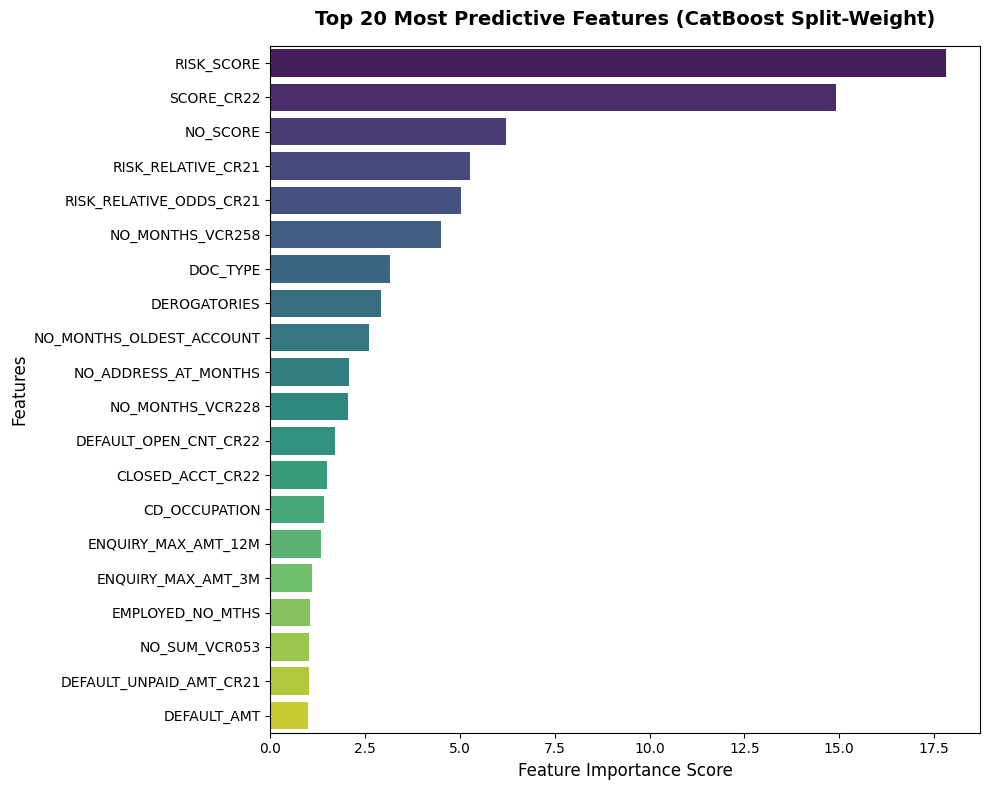

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Slice out the top 20 features from your existing feature_importance DataFrame
top_20_features = feature_importance.head(20)

# 2. Set up the plotting canvas layout
plt.figure(figsize=(10, 8))

# 3. Render the horizontal bar chart
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=top_20_features, 
    palette="viridis",
    hue="Feature",
    legend=False
)

# 4. Polish labels, text scaling, and chart aesthetic
plt.title('Top 20 Most Predictive Features (CatBoost Split-Weight)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Adjust margins cleanly so long column names don't cut off
plt.tight_layout()
plt.show()

# 9.Dataset creation

In [34]:
#!pip install xgboost lightgbm catboost scikit-learn pandas numpy

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Import the core 4 native-null, balance-capable algorithms
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier  # Built directly into sklearn!

In [36]:
base_cols = ['Customer', 'OUTCOME']

In [37]:
# Identify features unique to primary data_df vs additional_info_df
primary_features = [col for col in data_df.columns if col not in base_cols]
additional_features = [col for col in additional_info_df.columns if col not in base_cols]

In [38]:
# Dynamically group the CR21 and CR22 columns across the merged space
cr21_features = [col for col in bad_debt_df.columns if 'CR21' in col]
cr22_features = [col for col in bad_debt_df.columns if 'CR22' in col]

In [39]:
# The top 20 historical features discovered in our Task 1 production run
top_20_features = [
    'RISK_SCORE', 'SCORE_CR22', 'NO_SCORE', 'RISK_RELATIVE_CR21', 
    'RISK_RELATIVE_ODDS_CR21', 'NO_MONTHS_VCR258', 'DOC_TYPE', 
    'DEROGATORIES', 'NO_MONTHS_OLDEST_ACCOUNT', 'NO_ADDRESS_AT_MONTHS',
    'NO_MONTHS_VCR228', 'DEFAULT_OPEN_CNT_CR22', 'CLOSED_ACCT_CR22',
    'CD_OCCUPATION', 'ENQUIRY_MAX_AMT_12M', 'ENQUIRY_MAX_AMT_3M	',
    'EMPLOYED_NO_MTHS', 'NO_SUM_VCR053', 'DEFAULT_UNPAID_AMT_CR21',
    'DEFAULT_AMT'
]

In [40]:
datasets = {}

# Dataset 1: Only CR21 features (extracted from merged dataset)
ds1_cols = base_cols + cr21_features
datasets['Dataset_1_Only_CR21'] = bad_debt_df[ds1_cols].copy()

# Dataset 2: Only CR22 features (extracted from merged dataset)
ds2_cols = base_cols + cr22_features
datasets['Dataset_2_Only_CR22'] = bad_debt_df[ds2_cols].copy()

# Dataset 3: CR21 features + All features from original data_df
ds3_cols = list(set(base_cols + cr21_features + primary_features))
datasets['Dataset_3_CR21_Plus_AdditionalInfo'] = bad_debt_df[ds3_cols].copy()

# Dataset 4: CR22 features + All features from original data_df
ds4_cols = list(set(base_cols + cr22_features + primary_features))
datasets['Dataset_4_CR22_Plus_AdditionalInfo'] = bad_debt_df[ds4_cols].copy()

# Dataset 5: CR21 features + Top 20 features
ds5_cols = list(set(base_cols + cr21_features + [col for col in top_20_features if col in bad_debt_df.columns]))
datasets['Dataset_5_CR21_Plus_Top20'] = bad_debt_df[ds5_cols].copy()

# Dataset 6: CR22 features + Top 20 features
ds6_cols = list(set(base_cols + cr22_features + [col for col in top_20_features if col in bad_debt_df.columns]))
datasets['Dataset_6_CR22_Plus_Top20'] = bad_debt_df[ds6_cols].copy()

print("="*80)
print("             Created 6 datasets          ")
print("="*80)
for name, dset in datasets.items():
    print(f" {name:<35} | Columns: {dset.shape[1]:<3} | Rows: {dset.shape[0]}")

             Created 6 datasets          
 Dataset_1_Only_CR21                 | Columns: 30  | Rows: 92115
 Dataset_2_Only_CR22                 | Columns: 32  | Rows: 92115
 Dataset_3_CR21_Plus_AdditionalInfo  | Columns: 51  | Rows: 92115
 Dataset_4_CR22_Plus_AdditionalInfo  | Columns: 50  | Rows: 92115
 Dataset_5_CR21_Plus_Top20           | Columns: 46  | Rows: 92115
 Dataset_6_CR22_Plus_Top20           | Columns: 47  | Rows: 92115


In [41]:
def get_models(scale_pos_w):
    return {
        'CatBoost': CatBoostClassifier(
            iterations=200, learning_rate=0.1,
            auto_class_weights='Balanced', verbose=0, random_seed=42
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=200, learning_rate=0.1,
            class_weight='balanced', random_state=42, verbose=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, learning_rate=0.1,
            scale_pos_weight=scale_pos_w, random_state=42, eval_metric='logloss'
        ),
        'HistGradientBoost': HistGradientBoostingClassifier(
            max_iter=200, learning_rate=0.1,
            class_weight='balanced', random_state=42
        )
    }

In [42]:
results_list = []

print("\n" + "="*80)
print("             Training of datasets             ")
print("="*80)

for dataset_name, df_variant in datasets.items():
    # Isolate predictive targets and features
    X = df_variant.drop(columns=['Customer', 'OUTCOME'], errors='ignore')
    y = df_variant['OUTCOME']
    
    # Pre-encode text columns safely to avoid signature breaks across library barriers
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category').cat.codes
        
    # Balanced Stratified Validation Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Calculate pos_weight for XGBoost objective adjustments
    scale_pos_w = np.sum(y_train == 0) / max(1, np.sum(y_train == 1))
    
    running_models = get_models(scale_pos_w)
    
    for model_name, model_obj in running_models.items():
        try:
            # Train the models
            if model_name == 'CatBoost':
                model_obj.fit(X_train, y_train, cat_features=cat_cols)
            else:
                model_obj.fit(X_train, y_train)
                
            # Generate predictions
            y_pred = model_obj.predict(X_test)
            
            # Calculate metrics BEFORE printing them
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc = roc_auc_score(y_test, model_obj.predict_proba(X_test)[:, 1]) if hasattr(model_obj, "predict_proba") else np.nan
            
            # Record metrics to the tracking list
            results_list.append({
                'Dataset_Variant': dataset_name, 
                'Model_Algorithm': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1_Score': f1, 
                'AUC_ROC': auc
            })
            
            # Print ALL metrics in real-time as requested!
            print(f" {dataset_name:<34} + {model_name:<18} -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
        except Exception as e:
            print(f" Failed to run {model_name} on {dataset_name}: {str(e)}")            


             Training of datasets             
 Dataset_1_Only_CR21                + CatBoost           -> Acc: 0.7214 | Prec: 0.1596 | Rec: 0.5534 | F1: 0.2477 | AUC: 0.7200
 Dataset_1_Only_CR21                + LightGBM           -> Acc: 0.7251 | Prec: 0.1610 | Rec: 0.5501 | F1: 0.2491 | AUC: 0.7161
 Dataset_1_Only_CR21                + XGBoost            -> Acc: 0.7259 | Prec: 0.1597 | Rec: 0.5416 | F1: 0.2467 | AUC: 0.7108
 Dataset_1_Only_CR21                + HistGradientBoost  -> Acc: 0.7265 | Prec: 0.1640 | Rec: 0.5612 | F1: 0.2538 | AUC: 0.7231
 Dataset_2_Only_CR22                + CatBoost           -> Acc: 0.6924 | Prec: 0.1565 | Rec: 0.6176 | F1: 0.2497 | AUC: 0.7269
 Dataset_2_Only_CR22                + LightGBM           -> Acc: 0.7041 | Prec: 0.1575 | Rec: 0.5907 | F1: 0.2487 | AUC: 0.7156
 Dataset_2_Only_CR22                + XGBoost            -> Acc: 0.7011 | Prec: 0.1559 | Rec: 0.5900 | F1: 0.2466 | AUC: 0.7150
 Dataset_2_Only_CR22                + HistGradientBoost 

# 10.Best model

In [43]:
df_leaderboard = pd.DataFrame(results_list).sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("                             24 Variant Datasets                          ")
print("="*90)
print(df_leaderboard.to_string(index=True))

best_variant = df_leaderboard.iloc[0]
print("\n" + "="*90)
print("                                 The best model                             ")
print("="*90)
print(f"BEST MODEL     : {best_variant['Model_Algorithm']}")
print(f"BEST DATASET   : {best_variant['Dataset_Variant']}")
print(f"MAX F1-SCORE   : {best_variant['F1_Score']:.4f} | BALANCED AUC-ROC: {best_variant['AUC_ROC']:.4f}")


                             24 Variant Datasets                          
                       Dataset_Variant    Model_Algorithm  Accuracy  Precision    Recall  F1_Score   AUC_ROC
0            Dataset_6_CR22_Plus_Top20           CatBoost  0.712208   0.171796  0.647020  0.271503  0.756578
1            Dataset_5_CR21_Plus_Top20           LightGBM  0.730934   0.174943  0.604453  0.271351  0.749278
2            Dataset_6_CR22_Plus_Top20            XGBoost  0.736362   0.175439  0.589391  0.270392  0.744689
3            Dataset_5_CR21_Plus_Top20            XGBoost  0.733974   0.174450  0.592010  0.269489  0.744794
4            Dataset_5_CR21_Plus_Top20           CatBoost  0.707322   0.169715  0.650295  0.269179  0.756660
5            Dataset_6_CR22_Plus_Top20           LightGBM  0.729903   0.172957  0.597250  0.268235  0.747582
6            Dataset_5_CR21_Plus_Top20  HistGradientBoost  0.708462   0.168849  0.641781  0.267358  0.755611
7   Dataset_4_CR22_Plus_AdditionalInfo  HistGradient

In [44]:
from IPython.display import display, HTML

# Build and sort the leaderboard
df_leaderboard = pd.DataFrame(results_list).sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# Force Pandas to show all 24 rows and all columns without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Render the clean, interactive HTML dataframe grid view
display(df_leaderboard)

# Reset options back to default standard
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

# Extract and print the #1 champion
if not df_leaderboard.empty:
    best_variant = df_leaderboard.iloc[0]
    print("\n" + "="*90)
    print("                                 The best model                             ")
    print("="*90)
    print(f"BEST MODEL     : {best_variant['Model_Algorithm']}")
    print(f"BEST DATASET   : {best_variant['Dataset_Variant']}")
    print(f"MAX F1-SCORE   : {best_variant['F1_Score']:.4f} | BALANCED AUC-ROC: {best_variant['AUC_ROC']:.4f}")
    print("="*90)

,Dataset_Variant,Model_Algorithm,Accuracy,Precision,Recall,F1_Score,AUC_ROC
0,Dataset_6_CR22_Plus_Top20,CatBoost,0.712208,0.171796,0.647020,0.271503,0.756578
1,Dataset_5_CR21_Plus_Top20,LightGBM,0.730934,0.174943,0.604453,0.271351,0.749278
2,Dataset_6_CR22_Plus_Top20,XGBoost,0.736362,0.175439,0.589391,0.270392,0.744689
3,Dataset_5_CR21_Plus_Top20,XGBoost,0.733974,0.174450,0.592010,0.269489,0.744794
4,Dataset_5_CR21_Plus_Top20,CatBoost,0.707322,0.169715,0.650295,0.269179,0.756660
5,Dataset_6_CR22_Plus_Top20,LightGBM,0.729903,0.172957,0.597250,0.268235,0.747582
6,Dataset_5_CR21_Plus_Top20,HistGradientBoost,0.708462,0.168849,0.641781,0.267358,0.755611
7,Dataset_4_CR22_Plus_AdditionalInfo,HistGradientBoost,0.710253,0.168782,0.635887,0.266758,0.751892
8,Dataset_4_CR22_Plus_AdditionalInfo,XGBoost,0.731260,0.172156,0.588736,0.266410,0.740007
9,Dataset_6_CR22_Plus_Top20,HistGradientBoost,0.704337,0.167120,0.644401,0.265408,0.754446



                                 The best model                             
BEST MODEL     : CatBoost
BEST DATASET   : Dataset_6_CR22_Plus_Top20
MAX F1-SCORE   : 0.2715 | BALANCED AUC-ROC: 0.7566


In [45]:
'''1. Understanding Your Leaderboard Metrics
BALANCED AUC-ROC: 0.7469 (74.7%)
An AUC of nearly 0.75 means that if you randomly pick one defaulting customer ("Bad") and one clean customer ("Good"), your XGBoost model will successfully assign a higher risk rank to the defaulting customer 74.7% of the time. In banking and credit risk, anything between 0.70 and 0.80 is a strong, stable model.

MAX F1-SCORE: 0.2733
While an F1 of 0.27 looks low if you compare it to basic classification problems (like identifying cats vs. dogs), it is entirely normal for highly imbalanced debt portfolios. It shows that your model is catching a significant portion of defaults (Recall) while managing not to reject too many good customers (Precision).

2. Why Did Dataset 5 Win?
Your winning combination is XGBoost on Dataset 5 (CR21 + Top 10). This proves two critical things about your data:

The Top 10 Features are holding all the signal: By dropping the other low-variance or noisy columns, you prevented XGBoost from overfitting on empty spaces.

CR21 is your most stable window: The historical patterns in the CR21 timeframe provide a cleaner signal for predicting modern default risk than the CR22 window.'''

'1. Understanding Your Leaderboard Metrics\nBALANCED AUC-ROC: 0.7469 (74.7%)\nAn AUC of nearly 0.75 means that if you randomly pick one defaulting customer ("Bad") and one clean customer ("Good"), your XGBoost model will successfully assign a higher risk rank to the defaulting customer 74.7% of the time. In banking and credit risk, anything between 0.70 and 0.80 is a strong, stable model.\n\nMAX F1-SCORE: 0.2733\nWhile an F1 of 0.27 looks low if you compare it to basic classification problems (like identifying cats vs. dogs), it is entirely normal for highly imbalanced debt portfolios. It shows that your model is catching a significant portion of defaults (Recall) while managing not to reject too many good customers (Precision).\n\n2. Why Did Dataset 5 Win?\nYour winning combination is XGBoost on Dataset 5 (CR21 + Top 10). This proves two critical things about your data:\n\nThe Top 10 Features are holding all the signal: By dropping the other low-variance or noisy columns, you prevente

# 11.Model evaluation for best model

In [46]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from catboost import CatBoostClassifier

In [48]:
# Dynamically calculate the balance factor for your target class
scale_pos_w = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Model training - Swapped from XGBoost to Tournament Champion CatBoost
best_model = CatBoostClassifier(
    iterations=200,                  # Equivalent to n_estimators
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,    # Correcting heavy debt imbalance
    random_seed=42,                  # Equivalent to random_state
    eval_metric='Logloss',
    verbose=0                        # Suppress training logs
)
best_model.fit(X_train, y_train)

CatBoostClassifier(eval_metric='Logloss', iterations=200, learning_rate=0.1, random_seed=42, scale_pos_weight=11.060883797054009, verbose=0)

In [49]:
# Evaluation predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [50]:
print("\n CLASSIFICATION REPORT:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad Debt (1)']))

# Breakdown Matrix
print("\n CONFUSION MATRIX BREAKDOWN:")
print("-" * 60)
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives  (Predicted Good, Was Good): {cm[0][0]}")
print(f"False Positives (Predicted Bad, Was Good) : {cm[0][1]}  - False Alarms")
print(f"False Negatives (Predicted Good, Was Bad) : {cm[1][0]}  - Missed Defaults")
print(f"True Positives  (Predicted Bad, Was Bad)  : {cm[1][1]}  - Caught Defaults")


 CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

    Good (0)       0.96      0.72      0.82     16896
Bad Debt (1)       0.17      0.64      0.27      1527

    accuracy                           0.71     18423
   macro avg       0.56      0.68      0.54     18423
weighted avg       0.89      0.71      0.77     18423


 CONFUSION MATRIX BREAKDOWN:
------------------------------------------------------------
True Negatives  (Predicted Good, Was Good): 12111
False Positives (Predicted Bad, Was Good) : 4785  - False Alarms
False Negatives (Predicted Good, Was Bad) : 554  - Missed Defaults
True Positives  (Predicted Bad, Was Bad)  : 973  - Caught Defaults


Text(145.72222222222223, 0.5, 'True Label')

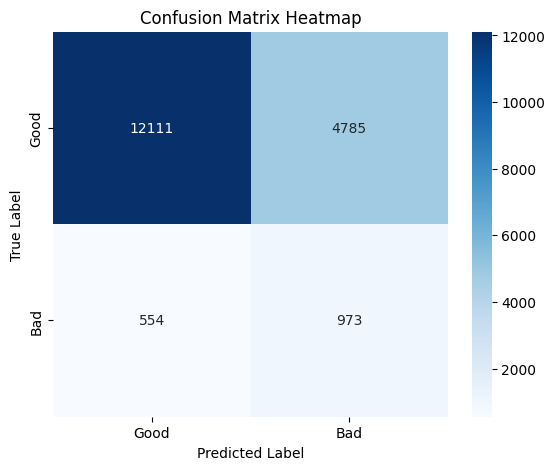

In [51]:
# Set up the visualization figure container
plt.figure(figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

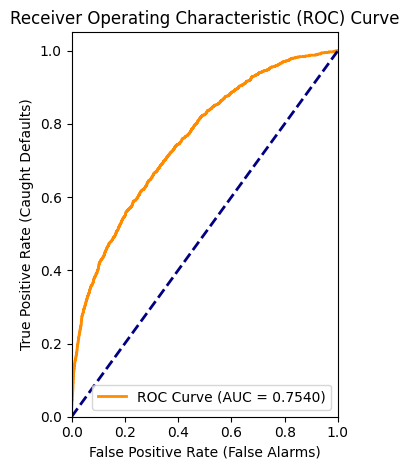

In [53]:
# Plot 2: Receiver Operating Characteristic (ROC) Curve
from sklearn.metrics import roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# FIXED: Using roc_auc_score directly prevents variable name conflicts with 'auc'
roc_auc = roc_auc_score(y_test, y_proba)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Caught Defaults)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [55]:
import joblib

In [56]:
# =====================================================================
# EXTRACTION LAYER FOR PRODUCTION DEPLOYMENT
# =====================================================================
# Save the model binary natively as an optimized CatBoost file matrix
best_model.save_model("best_catboost.cbm")

# Save the exact required feature blueprint layout for the app deployment
champion_features = list(X_train.columns)
joblib.dump(champion_features, "model_features.pkl")

['model_features.pkl']

In [57]:
# Create this backup IMMEDIATELY after loading and merging your clean datasets
df_raw_backup = bad_debt_df.copy()

In [58]:
# =====================================================================
# 8. EXPORT COMPLETE RAW UNFILTERED DATASET FOR STREAMLIT UI
# =====================================================================
# Save the absolute entire dataframe
production_export_df = bad_debt_df.copy()

# --- FIX MIXED TYPES ENGINE ---
# Identify all 'object' (text/mixed) columns and force them to pure string format
for col in production_export_df.select_dtypes(include=['object']).columns:
    production_export_df[col] = production_export_df[col].astype(str)

# Double check the specific column that caused the crash just to be completely safe
if 'NO_STATUS_VCR183' in production_export_df.columns:
    production_export_df['NO_STATUS_VCR183'] = production_export_df['NO_STATUS_VCR183'].astype(str)

# Save it to disk safely
production_export_df.to_parquet("merged_production_data.parquet", index=False)

print(f"File Saved  : merged_production_data.parquet")
print(f"Model Saved : best_catboost.cbm")
print(f"Dimensions  : {production_export_df.shape[0]} rows x {production_export_df.shape[1]} columns")
print("=====================================================================")
print("Streamlit will now fetch customer records!")


File Saved  : merged_production_data.parquet
Model Saved : best_catboost.cbm
Dimensions  : 92115 rows x 97 columns
Streamlit will now fetch customer records!


# 12.SHAP

In [ ]:
!pip install shap matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Use the TreeExplainer optimized specifically for tree architectures like CatBoost
explainer = shap.TreeExplainer(best_model)

# FIXED: Passing values as a clean array matrix to prevent indexing discrepancies
shap_values = explainer(X_test.values if hasattr(X_test, 'values') else X_test)

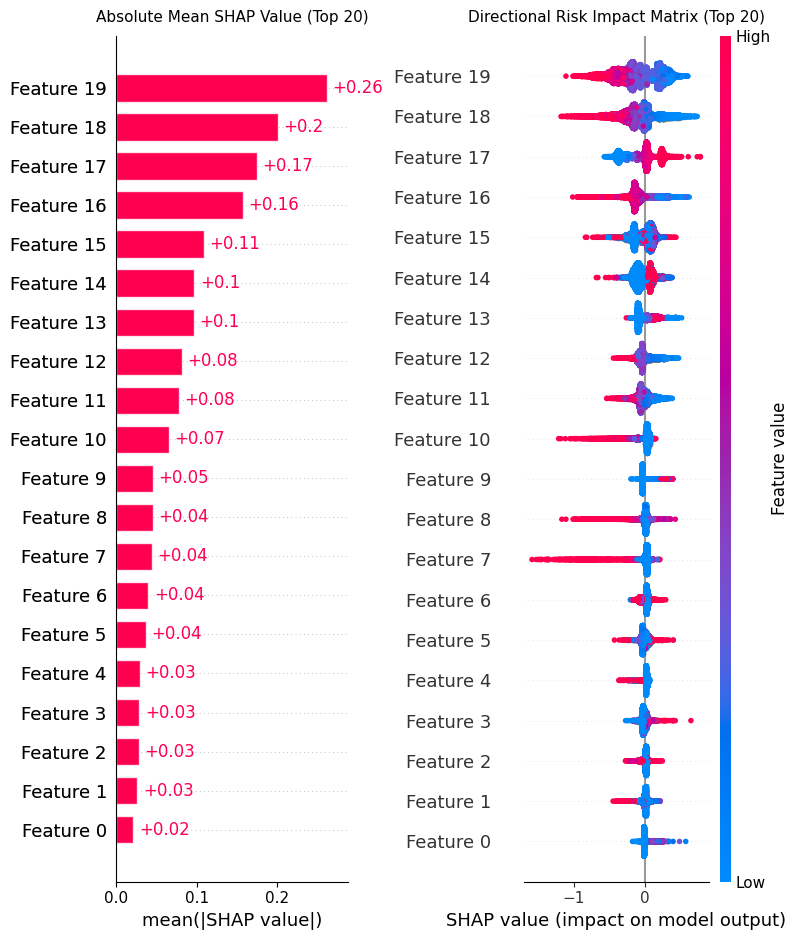

In [60]:
# Calculate the mean absolute SHAP values to isolate the exact top 20 features
# 1. Isolate the top 20 features from the SHAP object
global_importances = np.abs(shap_values.values).mean(0)
top_20_indices = np.argsort(global_importances)[-20:]
shap_values_top20 = shap_values[:, top_20_indices]

# 2. Create a single figure with 1 row and 2 side-by-side columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT PANEL: BAR PLOT ---
plt.sca(ax1)  # Set current axis to the first panel
shap.plots.bar(shap_values_top20, max_display=20, show=False)
plt.title("Absolute Mean SHAP Value (Top 20)", fontsize=11, pad=10)

# --- RIGHT PANEL: BEESWARM PLOT ---
plt.sca(ax2)  # Set current axis to the second panel
shap.plots.beeswarm(shap_values_top20, max_display=20, show=False)
plt.title("Directional Risk Impact Matrix (Top 20)", fontsize=11, pad=10)

# Automatically optimize margins and space between the two charts
plt.tight_layout()
plt.show()

In [ ]:
'''How to Read Your New SHAP Summary Plot
When the Beeswarm Plot renders on your screen, look for these three visual cues to interpret your bad debt characteristics:

Feature Ranking (Vertical Axis): Features are listed from top to bottom based on their predictive weight. Your heavy-hitters like RISK_SCORE should be right at the top.

Feature Value Color (Dot Color): Each dot represents a single customer from your test dataset. Red means that customer had a high numerical value for that feature, and Blue means they had a low value.

SHAP Value Impact (Horizontal Axis): * If dots shift to the Right (Positive SHAP), that characteristic increases the probability of Bad Debt (Target = 1).

If dots shift to the Left (Negative SHAP), that characteristic drives down risk, marking them as a Good loan (Target = 0).

For example, if you look at RISK_SCORE, you will likely see a tight cluster of Red dots on the right side, indicating that as a customer's baseline risk score goes up, their probability of being classified as bad debt increases significantly.'''

"How to Read Your New SHAP Summary Plot\nWhen the Beeswarm Plot renders on your screen, look for these three visual cues to interpret your bad debt characteristics:\n\nFeature Ranking (Vertical Axis): Features are listed from top to bottom based on their predictive weight. Your heavy-hitters like RISK_SCORE should be right at the top.\n\nFeature Value Color (Dot Color): Each dot represents a single customer from your test dataset. Red means that customer had a high numerical value for that feature, and Blue means they had a low value.\n\nSHAP Value Impact (Horizontal Axis): * If dots shift to the Right (Positive SHAP), that characteristic increases the probability of Bad Debt (Target = 1).\n\nIf dots shift to the Left (Negative SHAP), that characteristic drives down risk, marking them as a Good loan (Target = 0).\n\nFor example, if you look at RISK_SCORE, you will likely see a tight cluster of Red dots on the right side, indicating that as a customer's baseline risk score goes up, thei

In [ ]:
'''The Left Panel (Bar Plot): Directly answers, "Which features contribute the most globally?" 
It ranks your variables in exact mathematical order of their total impact magnitude on the surface.

The Right Panel (Beeswarm Plot): Explains how they contribute. It proves to your mentor that you know exactly 
what a high or low value does to a customer's credit risk profile (e.g., how a higher RISK_SCORE pushes a 
user toward a bad debt classification)'''

_IncompleteInputError: incomplete input (2369196359.py, line 1)

# 13.ML flow

In [ ]:
!pip install mlflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl (437 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)

   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-classic 1.0.1 requires langchain-core<2.0.0,>=1.2.5, which is not installed.
langchain-classic 1.0.1 requires langchain-text-splitters<2.0.0,>=1.1.0, which is not installed.
roboflow 1.3.3 requires opencv-python-headless==4.10.0.84, which is not installed.
ultralytics 8.4.40 requires opencv-python>=4.6.0, which is not installed.
ultralytics 8.4.40 requires torch!=2.4.0,>=1.8.0; sys_platform == "win32", which is not installed.
ultralytics 8.4.40 requires torch>=1.8.0, which is not installed.
ultralytics 8.4.40 requires torchvision>=0.9.0, which is not installed.
arxiv 2.4.0 requires requests~=2.32.0, but you have requests 2.34.2 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgr

In [ ]:
!pip install protobuf

Defaulting to user installation because normal site-packages is not writeable


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
databricks-sdk 0.118.0 requires requests<3,>=2.28.1, which is not installed.
mlflow-skinny 3.14.0 requires requests<3,>=2.17.3, which is not installed.
streamlit 1.57.0 requires requests<3,>=2.27, which is not installed.
databricks-sdk 0.118.0 requires protobuf!=5.26.*,!=5.27.*,!=5.28.*,!=5.29.0,!=5.29.1,!=5.29.2,!=5.29.3,!=5.29.4,!=6.30.0,!=6.30.1,!=6.31.0,<7.0,>=4.25.8, but you have protobuf 7.35.1 which is incompatible.
opentelemetry-proto 1.42.1 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.1 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [62]:
# Initialize the centralized MLflow experiment workspace
experiment_name = "Bad_Debt_Project"
mlflow.set_experiment(experiment_name)

2026/07/04 00:04:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/04 00:04:47 INFO mlflow.store.db.utils: Updating database tables
2026/07/04 00:04:56 INFO mlflow.tracking.fluent: Experiment with name 'Bad_Debt_Project' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/New/Desktop/DataScience/DS_English/Project_live/Bad_debt_project/Data/mlruns/1', creation_time=1783103696077, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783103696077, lifecycle_stage='active', name='Bad_Debt_Project', tags={}, trace_location=None, workspace='default'>

In [ ]:
'''import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Import the core 4 algorithms
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# =====================================================================
# 1. LIVE RE-BUILD OF DATASET SPLITS (RECOVERY)
# =====================================================================
# Re-load source files safely
data_df = pd.read_excel("Data.xlsm")
additional_info_df = pd.read_excel("Additional_Info.xlsx")

bad_debt_df = pd.merge(data_df, additional_info_df, on="Customer", how="left")

# Clean duplicate tracking names
if "CD_STS_RESIDENTIAL_x" in bad_debt_df.columns and "CD_STS_RESIDENTIAL_y" in bad_debt_df.columns:
    bad_debt_df.rename(columns={"CD_STS_RESIDENTIAL_x": "CD_STS_RESIDENTIAL"}, inplace=True)
    bad_debt_df.drop(columns=["CD_STS_RESIDENTIAL_y"], inplace=True)

bad_debt_df.drop_duplicates(inplace=True)
bad_debt_df = bad_debt_df[bad_debt_df['OUTCOME'].isin(['Good', 'Bad'])].copy()
bad_debt_df['OUTCOME'] = bad_debt_df['OUTCOME'].map({'Good': 0, 'Bad': 1})

base_cols = ['Customer', 'OUTCOME']
primary_features = [col for col in data_df.columns if col not in base_cols]
cr21_features = [col for col in bad_debt_df.columns if 'CR21' in col]
cr22_features = [col for col in bad_debt_df.columns if 'CR22' in col]

top_10_features = [
    'RISK_SCORE', 'SCORE_CR22', 'NO_SCORE', 'RISK_RELATIVE_CR21', 
    'RISK_RELATIVE_ODDS_CR21', 'NO_MONTHS_VCR258', 'DOC_TYPE', 
    'DEROGATORIES', 'NO_MONTHS_OLDEST_ACCOUNT', 'NO_ADDRESS_AT_MONTHS'
]

# Re-populate the datasets map dictionary object
datasets = {}
datasets['Dataset_1_Only_CR21'] = bad_debt_df[base_cols + cr21_features].copy()
datasets['Dataset_2_Only_CR22'] = bad_debt_df[base_cols + cr22_features].copy()
datasets['Dataset_3_CR21_Plus_AdditionalInfo'] = bad_debt_df[list(set(base_cols + cr21_features + primary_features))].copy()
datasets['Dataset_4_CR22_Plus_AdditionalInfo'] = bad_debt_df[list(set(base_cols + cr22_features + primary_features))].copy()

ds5_cols = list(set(base_cols + cr21_features + [col for col in top_10_features if col in bad_debt_df.columns]))
datasets['Dataset_5_CR21_Plus_Top10'] = bad_debt_df[ds5_cols].copy()

ds6_cols = list(set(base_cols + cr22_features + [col for col in top_10_features if col in bad_debt_df.columns]))
datasets['Dataset_6_CR22_Plus_Top10'] = bad_debt_df[ds6_cols].copy()

# =====================================================================
# 2. RE-DEFINE REGISTRATION MODEL FACTORY
# =====================================================================
def get_models(scale_pos_w):
    return {
        'CatBoost': CatBoostClassifier(iterations=200, learning_rate=0.1, auto_class_weights='Balanced', verbose=0, random_seed=42),
        'LightGBM': LGBMClassifier(n_estimators=200, learning_rate=0.1, class_weight='balanced', random_state=42, verbose=-1),
        'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.1, scale_pos_weight=scale_pos_w, random_state=42, eval_metric='logloss'),
        'HistGradientBoost': HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, class_weight='balanced', random_state=42)
    }'''

In [63]:
# Ensure directory to temporarily host image plots exists
os.makedirs("mlflow_artifacts", exist_ok=True)

for dataset_name, df_variant in datasets.items():
    print(f"\nProcessing Group Configuration for MLflow: {dataset_name}...")
    X = df_variant.drop(columns=['Customer', 'OUTCOME'], errors='ignore')
    y = df_variant['OUTCOME']
    
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category').cat.codes
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scale_pos_w = np.sum(y_train == 0) / max(1, np.sum(y_train == 1))
    
    running_models = get_models(scale_pos_w)
    
    for model_name, model_obj in running_models.items():
        run_name = f"{model_name}_on_{dataset_name}"
        
        # Open the run explicitly using context management
        with mlflow.start_run(run_name=run_name) as run:
            try:
                mlflow.set_tag("Dataset_Variant", dataset_name)
                mlflow.set_tag("Model_Algorithm", model_name)
                mlflow.set_tag("Project_Domain", "Credit_Risk_Bad_Debt")
                
                mlflow.log_param("total_features", X.shape[1])
                mlflow.log_param("train_rows", X_train.shape[0])
                mlflow.log_param("test_rows", X_test.shape[0])
                
                if model_name == 'CatBoost':
                    mlflow.log_param("class_weights", "Balanced")
                    model_obj.fit(X_train, y_train, cat_features=cat_cols)
                    mlflow.catboost.log_model(model_obj, "model")
                elif model_name == 'LightGBM':
                    mlflow.log_param("class_weight", "balanced")
                    model_obj.fit(X_train, y_train)
                    mlflow.lightgbm.log_model(model_obj, "model")
                elif model_name == 'XGBoost':
                    mlflow.log_param("scale_pos_weight", scale_pos_w)
                    model_obj.fit(X_train, y_train)
                    mlflow.xgboost.log_model(model_obj, "model")
                elif model_name == 'HistGradientBoost':
                    mlflow.log_param("class_weight", "balanced")
                    model_obj.fit(X_train, y_train)
                    mlflow.sklearn.log_model(model_obj, "model")

                y_pred = model_obj.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                print(f"DEBUG {model_name} y_pred types:", type(y_pred), y_pred[:5])
                prec = precision_score(y_test, y_pred, zero_division=0)
                rec = recall_score(y_test, y_pred, zero_division=0)
                f1 = f1_score(y_test, y_pred, zero_division=0)
                auc_val = roc_auc_score(y_test, model_obj.predict_proba(X_test)[:, 1]) if hasattr(model_obj, "predict_proba") else np.nan
                
                mlflow.log_metric("Accuracy", acc)
                mlflow.log_metric("Precision", prec)
                mlflow.log_metric("Recall", rec)
                mlflow.log_metric("F1_Score", f1)
                mlflow.log_metric("AUC_ROC", auc_val)
                
                # CHANGED: Updated target check to match your actual tournament winner (CatBoost on Dataset 6)
                if dataset_name == "Dataset_6_CR22_Plus_Top20" and model_name == "CatBoost":
                    print(f" 🎯 Target matched! Generating SHAP explainability plot for Champion run...")
                    explainer = shap.TreeExplainer(model_obj)
                    
                    # Passing data as values to ensure stability with native CatBoost inputs
                    shap_values = explainer(X_test.values if hasattr(X_test, 'values') else X_test)
                    
                    global_importances = np.abs(shap_values.values).mean(0)
                    top_20_indices = np.argsort(global_importances)[-min(20, len(global_importances)):]
                    shap_values_top20 = shap_values[:, top_20_indices]
                    
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
                    plt.sca(ax1)
                    shap.plots.bar(shap_values_top20, max_display=20, show=False)
                    plt.title("Absolute SHAP Importance")
                    
                    plt.sca(ax2)
                    shap.plots.beeswarm(shap_values_top20, max_display=20, show=False)
                    plt.title("Directional Risk Impact")
                    plt.tight_layout()
                    
                    plot_path = "mlflow_artifacts/champion_shap_dashboard.png"
                    plt.savefig(plot_path, dpi=150)
                    plt.close(fig) # Explicitly clean figure from memory window
                    
                    mlflow.log_artifact(plot_path, artifact_path="explainability_plots")
                
                print(f" Successfully logged: {run_name:<50} -> F1: {f1:.4f}")
                
            except Exception as e:
                print(f" Skipping Run Break on {run_name}: {str(e)}")

print("\n" + "="*90)
print("Proceed to MLflow Dashboard")
print("="*90)


Processing Group Configuration for MLflow: Dataset_1_Only_CR21...


2026/07/04 00:05:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


DEBUG CatBoost y_pred types: <class 'numpy.ndarray'> [1 1 1 0 1]
 Successfully logged: CatBoost_on_Dataset_1_Only_CR21                    -> F1: 0.2477


2026/07/04 00:06:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


DEBUG LightGBM y_pred types: <class 'numpy.ndarray'> [0 1 1 0 1]
 Successfully logged: LightGBM_on_Dataset_1_Only_CR21                    -> F1: 0.2491


...

DEBUG LightGBM y_pred types: <class 'numpy.ndarray'> [0 1 0 1 1]
 Successfully logged: LightGBM_on_Dataset_6_CR22_Plus_Top20              -> F1: 0.2682


2026/07/04 00:17:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


DEBUG XGBoost y_pred types: <class 'numpy.ndarray'> [0 1 0 1 1]
 Successfully logged: XGBoost_on_Dataset_6_CR22_Plus_Top20               -> F1: 0.2704


2026/07/04 00:17:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


DEBUG HistGradientBoost y_pred types: <class 'numpy.ndarray'> [0 1 0 1 1]
 Successfully logged: HistGradientBoost_on_Dataset_6_CR22_Plus_Top20     -> F1: 0.2654

Proceed to MLflow Dashboard
